# Tarea 1 --- IELE756

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Team members:** Felipe Velásquez, Matías Moraga

**Comunas:** El Bosque, Lo Espejo, Isla de Maipo y Pirque

**Fecha:** 16/04/2026

# **Parte A: ENO – Enfermedades de Notificación Obligatoria**

A.0 Carga de Datos y Limpieza

A.0.1 Load the ENO dataset

In [3]:
import pandas as pd
from google.colab import drive

#Montar Drive para acceder a los archivos
drive.mount('/content/drive')

#Definimos las columnas
eno_cols = ["ENO", "anho_notificacion", "region", "codigo_comuna_residencia",
            "nacionalidad", "sexo", "grupo_edad", "nombre_instruccion",
            "cie_10_diagnostico", "diagnostico", "pais_contagio"]

#Ruta
path_eno_file = "/content/drive/MyDrive/Colab Notebooks/20241218_base_eno_final.csv"

#Carga del dataset completo
eno = pd.read_csv(path_eno_file,
                 sep=";",
                 encoding="utf-8-sig",
                 usecols=eno_cols)

#Reportar shape e info
print("A.0.1 Reporte de carga:")
print(f"Shape: {eno.shape}")
print("-" * 30)
eno.info()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
A.0.1 Reporte de carga:
Shape: (333300, 11)
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333300 entries, 0 to 333299
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   region                    333300 non-null  object
 1   nacionalidad              333300 non-null  object
 2   cie_10_diagnostico        333300 non-null  object
 3   diagnostico               333300 non-null  object
 4   anho_notificacion         333300 non-null  int64 
 5   ENO                       333300 non-null  object
 6   nombre_instruccion        333300 non-null  object
 7   pais_contagio             333300 non-null  object
 8   sexo                      333300 non-null  object
 9   grupo_edad                333300 non-null  object
 10  codigo_comuna_reside

A.0.2 Filter comunas

In [4]:
#Definimos comunas (El Bosque, Lo Espejo, Isla de Maipo y Pirque)
MY_COMUNAS = [13105, 13116, 13603, 13202]
my_comunas_str = [str(c) for c in MY_COMUNAS]

#Filtrar
eno_com = eno[eno["codigo_comuna_residencia"].isin(my_comunas_str)].copy()

print(f"\nRows in my comunas: {len(eno_com):,}")

# Reportar anonimizados en el dataset completo
anon_count = len(eno[eno["codigo_comuna_residencia"] == "*****"])
print(f"Rows with codigo_comuna_residencia == '*****' (anonymized): {anon_count:,}")


Rows in my comunas: 2,141
Rows with codigo_comuna_residencia == '*****' (anonymized): 148,217


A.0.3 Clean the nationality variable

In [5]:
# Reportar distribución en los datos filtrados
print("\nDistribution of nacionalidad in filtered data:")
print(eno_com["nacionalidad"].value_counts(dropna=False))


Distribution of nacionalidad in filtered data:
nacionalidad
Chile          1143
Desconocido     796
Extranjero      202
Name: count, dtype: int64


A.0.4 Report the time span

In [6]:
print(f"\nRange of anho_notificacion: {eno_com['anho_notificacion'].min()} to {eno_com['anho_notificacion'].max()}")

# Tabla de notificaciones por año
tabla_anual = eno_com.groupby("anho_notificacion").size().reset_index(name="Notifications")
print("\nNotifications per year:")
display(tabla_anual)


Range of anho_notificacion: 2007 to 2024

Notifications per year:


,anho_notificacion,Notifications
0,2007,103
1,2008,75
2,2009,80
3,2010,77
4,2011,111
5,2012,76
6,2013,94
7,2014,99
8,2015,138
9,2016,74


A.1 Notification Trends Over Time


A.1.1 Overall trend


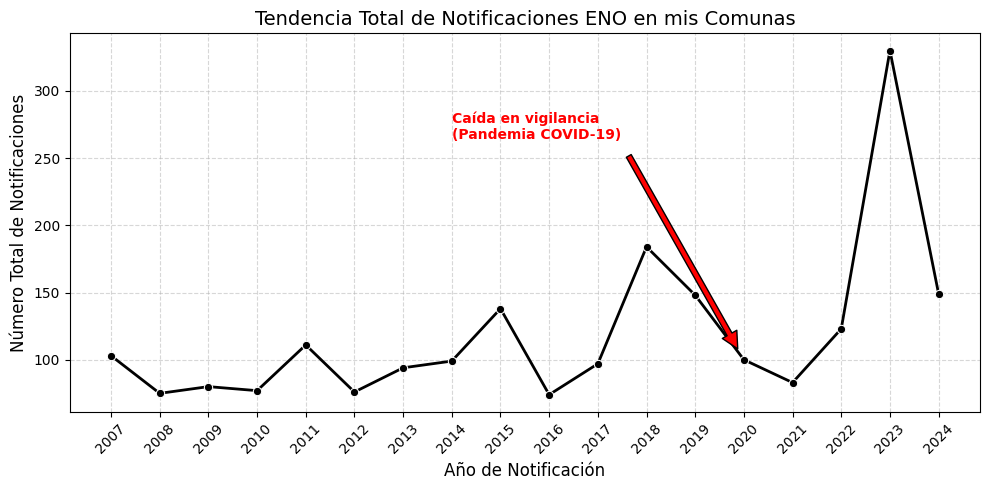

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# A.1.1 Overall trend
# Agrupamos por año contando el total de filas (independiente de la nacionalidad)
overall_trend = eno_com.groupby('anho_notificacion').size().reset_index(name='total_notifications')

plt.figure(figsize=(10, 5))
sns.lineplot(data=overall_trend, x='anho_notificacion', y='total_notifications',
             marker='o', color='black', linewidth=2)

# Anotación sobre la caída por COVID-19 (visualmente notable en 2020)
plt.annotate('Caída en vigilancia\n(Pandemia COVID-19)',
             xy=(2020, overall_trend[overall_trend.anho_notificacion==2020]['total_notifications'].iloc[0]),
             xytext=(2014, overall_trend['total_notifications'].max()*0.8),
             arrowprops=dict(facecolor='red', shrink=0.05),
             fontsize=10, color='red', fontweight='bold')

plt.title('Tendencia Total de Notificaciones ENO en mis Comunas', fontsize=14)
plt.xlabel('Año de Notificación', fontsize=12)
plt.ylabel('Número Total de Notificaciones', fontsize=12)
plt.xticks(range(int(eno_com['anho_notificacion'].min()), int(eno_com['anho_notificacion'].max()) + 1), rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Se observa una caída significativa en 2020-2021 debido a que los recursos de vigilancia se enfocaron en COVID-19, afectando la notificación de otras enfermedades obligatorias.

A.1.2 Trend by nationality

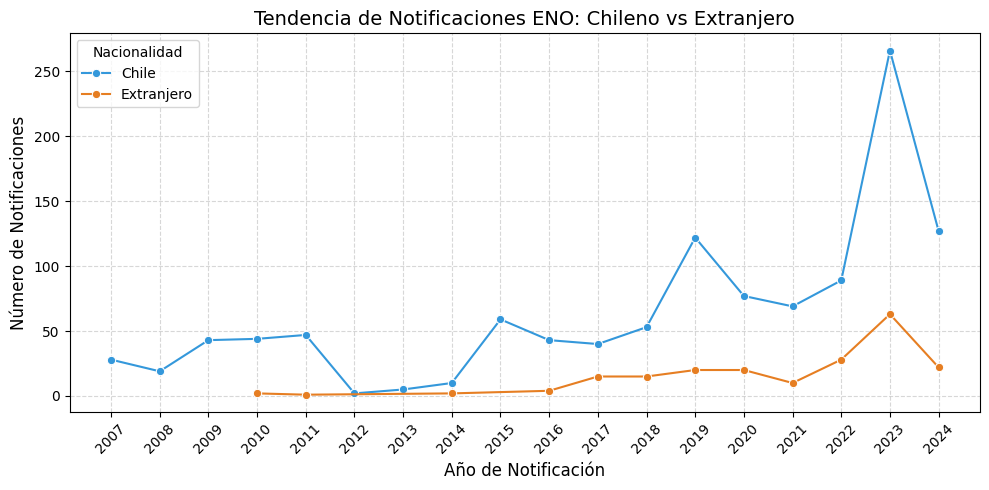

In [67]:
# A.1.2 Trend by nationality
# 1. Filtramos para excluir "Desconocido"
eno_nac = eno_com[eno_com["nacionalidad"] != "Desconocido"].copy()

# 2. Agrupamos por año y nacionalidad
trend_by_nac = eno_nac.groupby(['anho_notificacion', 'nacionalidad']).size().reset_index(name='count')

plt.figure(figsize=(10, 5))
sns.lineplot(data=trend_by_nac, x='anho_notificacion', y='count',
             hue='nacionalidad', marker='o', palette=['#3498db', '#e67e22'])

plt.title('Tendencia de Notificaciones ENO: Chileno vs Extranjero', fontsize=14)
plt.xlabel('Año de Notificación', fontsize=12)
plt.ylabel('Número de Notificaciones', fontsize=12)
plt.xticks(range(int(eno_com['anho_notificacion'].min()), int(eno_com['anho_notificacion'].max()) + 1), rotation=45)
plt.legend(title='Nacionalidad')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

¿Ha cambiado el share de extranjeros?
Se observa que mientras las notificaciones de chilenos se mantienen en un rango histórico, las de población extranjera muestran un incremento gradual en los últimos años (2017-2024), lo cual es consistente con el aumento de la población migrante en la Región Metropolitana.

A.2 Disease Profiles

A.2.1 Top diseases overall

/tmp/ipykernel_27638/120719594.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_diseases.values, y=top_10_diseases.index, palette="viridis")


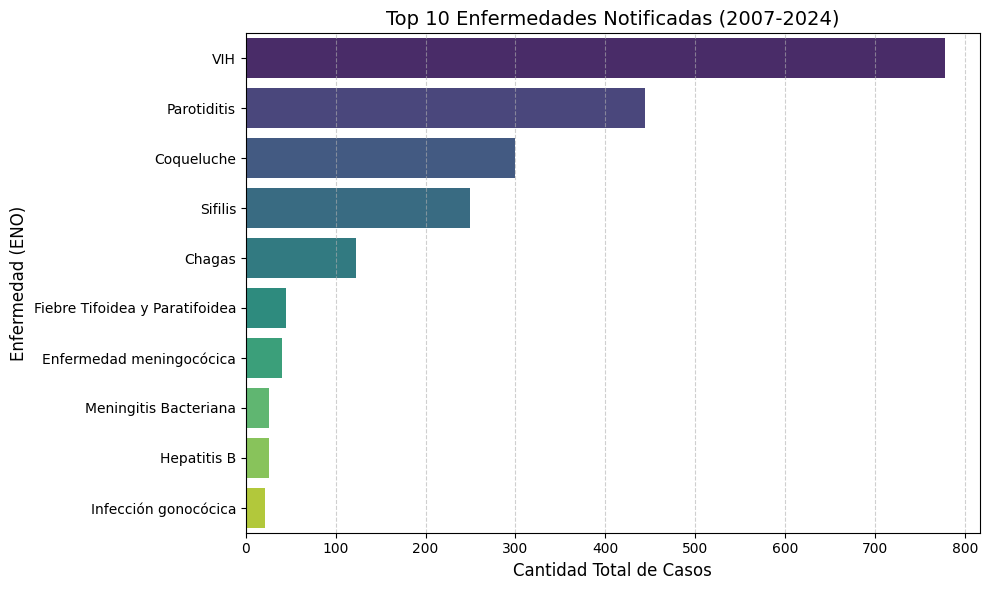

In [65]:
# A.2.1 Top 10 notified diseases overall
top_10_diseases = eno_com["ENO"].value_counts().head(10)

plt.figure(figsize=(10, 6))
# Usamos un gráfico de barras horizontales como pide el PDF
sns.barplot(x=top_10_diseases.values, y=top_10_diseases.index, palette="viridis")

plt.title('Top 10 Enfermedades Notificadas (2007-2024)', fontsize=14)
plt.xlabel('Cantidad Total de Casos', fontsize=12)
plt.ylabel('Enfermedad (ENO)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

A.2.2 Disease profiles by nationality

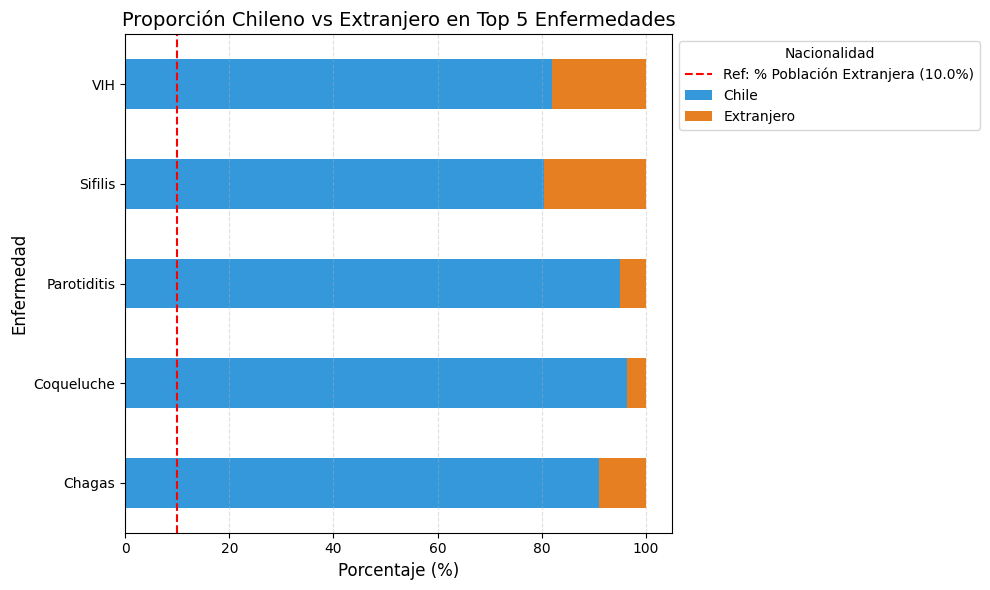

In [64]:
# A.2.2 Disease profiles by nationality (Top 5)

# 1. Identificar las top 5 enfermedades del conteo general
top_5_list = eno_com["ENO"].value_counts().head(5).index

# 2. Filtrar el dataframe que no tiene "Desconocidos" para estas 5 enfermedades
eno_top5 = eno_nac[eno_nac["ENO"].isin(top_5_list)]

# 3. Calcular el share (proporción porcentual)
# Creamos una tabla cruzada y normalizamos por filas (index)
prop_data = pd.crosstab(eno_top5["ENO"], eno_top5["nacionalidad"], normalize='index') * 100

# 4. Graficar como barras apiladas (stacked bar chart)
prop_data.plot(kind='barh', stacked=True, figsize=(10, 6), color=['#3498db', '#e67e22'])

# 5. Añadir línea de referencia del % de extranjeros (Contextualización)
# Supongamos un 10% basado en tus resultados de la Tarea 1 (Ajusta este valor si es necesario)
PCT_FOREIGN_REF = 10.0
plt.axvline(x=PCT_FOREIGN_REF, color='red', linestyle='--', label=f'Ref: % Población Extranjera ({PCT_FOREIGN_REF}%)')

plt.title('Proporción Chileno vs Extranjero en Top 5 Enfermedades', fontsize=14)
plt.xlabel('Porcentaje (%)', fontsize=12)
plt.ylabel('Enfermedad', fontsize=12)
plt.legend(title='Nacionalidad', bbox_to_anchor=(1, 1))
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

¿Hay enfermedades con sobre-representación de extranjeros?
Si una barra naranja supera la línea roja del 10.0%, significa que esa enfermedad afecta proporcionalmente más a la población extranjera que su peso en la población total.

A.2.3 Age-group distribution for the top disease

Analizando la distribución de edad para la enfermedad top: VIH


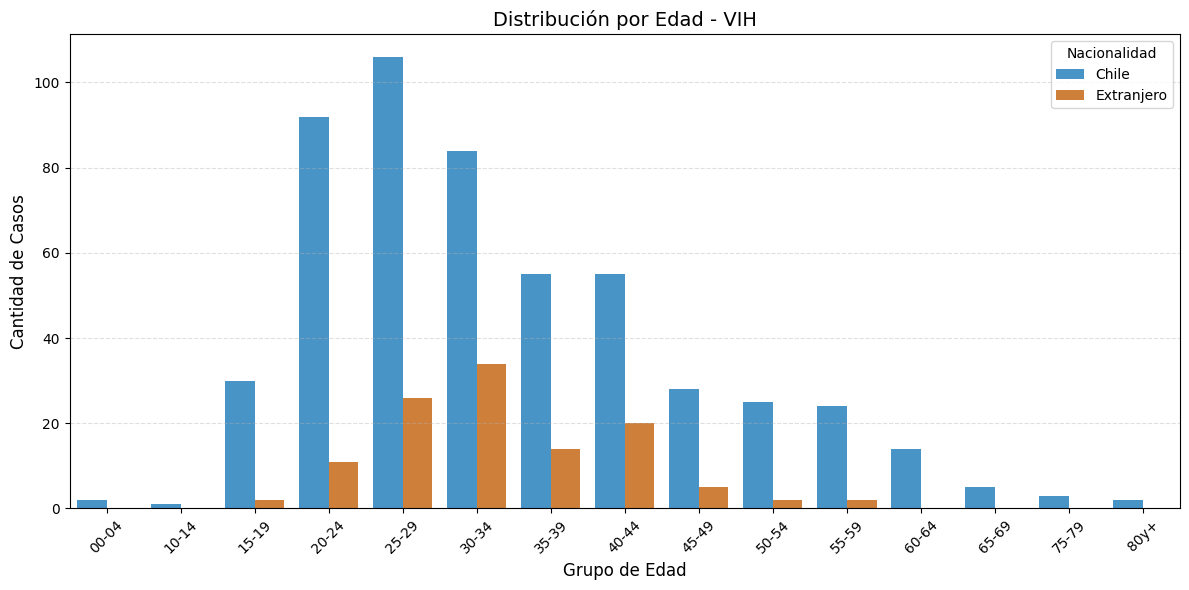

In [63]:
# A.2.3 Age-group distribution for the top disease

# 1. Identificar la enfermedad más común
top_1_disease = eno_com["ENO"].value_counts().idxmax()
print(f"Analizando la distribución de edad para la enfermedad top: {top_1_disease}")

# 2. Filtrar datos (sin desconocidos) para esa enfermedad
eno_top1 = eno_nac[eno_nac["ENO"] == top_1_disease]

# 3. Graficar
plt.figure(figsize=(12, 6))

# Ordenamos los grupos de edad alfabéticamente/numéricamente para que el eje X tenga sentido
age_order = sorted(eno_top1["grupo_edad"].dropna().unique())

sns.countplot(data=eno_top1, x="grupo_edad", hue="nacionalidad",
              order=age_order, palette=['#3498db', '#e67e22'])

plt.title(f'Distribución por Edad - {top_1_disease}', fontsize=14)
plt.xlabel('Grupo de Edad', fontsize=12)
plt.ylabel('Cantidad de Casos', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Nacionalidad')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

¿Hay diferencias en el perfil de edad?
Observa si los extranjeros se concentran en edades laborales (20-40) mientras
que los chilenos tienen una distribución más amplia (incluyendo niños o adultos mayores).

A.3 Spatial View

A.3.1 Notification counts by comuna

/tmp/ipykernel_27638/2257346671.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=spatial_stats, x='nombre_comuna', y='eno_total_count', palette='viridis', ax=ax1)
/tmp/ipykernel_27638/2257346671.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=spatial_stats, x='nombre_comuna', y='eno_rate_per_10k', palette='magma', ax=ax2)


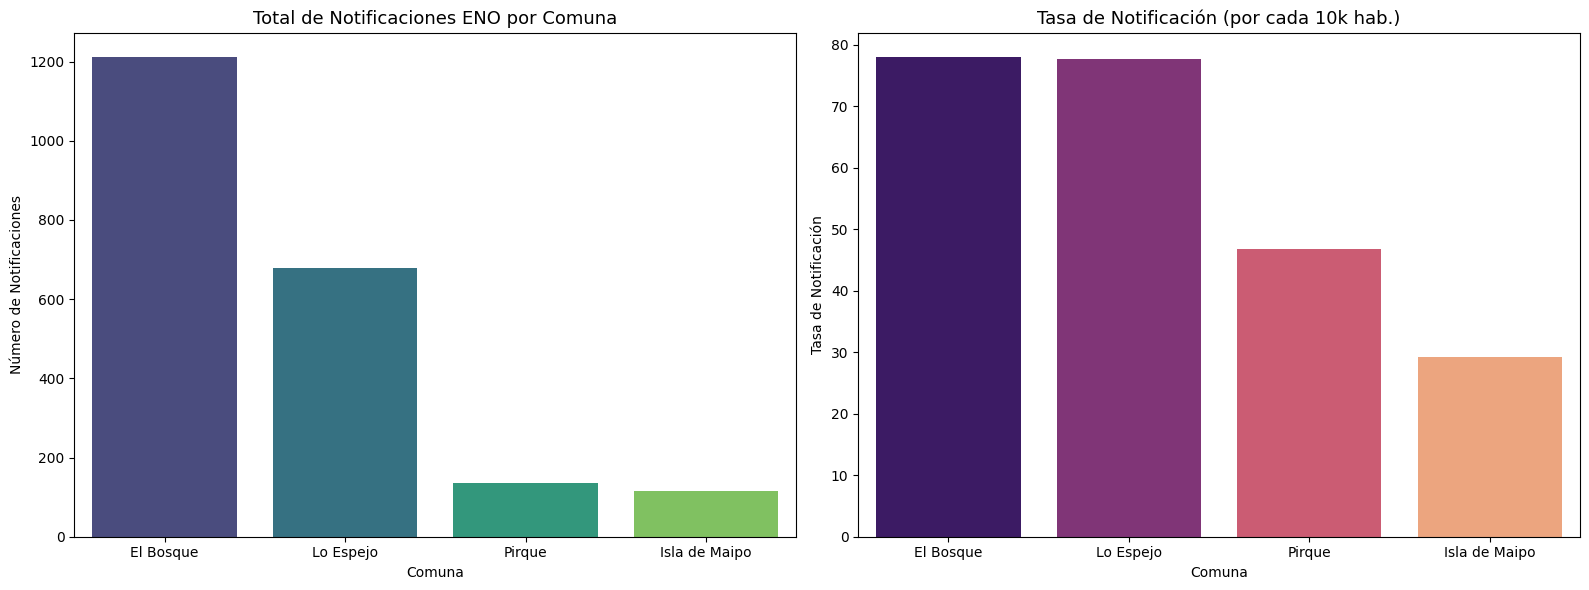

--------------------------------------------------------------------------------
NOTA IMPORTANTE (Caveat):
Las cifras de notificaciones ENO son subestimaciones debido a que un gran porcentaje
de los datos (~45% a nivel nacional) están anonimizados con '*****' en el origen.
--------------------------------------------------------------------------------


In [62]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Cargar el resumen de la Tarea 1 desde tu Drive
path_t1 = "/content/drive/MyDrive/Colab Notebooks/Tarea 1/tarea1_comuna_summary.csv"
t1_summary = pd.read_csv(path_t1)

#Calcular conteos totales de notificaciones por código de comuna en ENO
#Convertimos a int para asegurar que el cruce (merge) sea correcto
eno_counts = eno_com.groupby("codigo_comuna_residencia").size().reset_index(name='eno_total_count')
eno_counts["codigo_comuna_residencia"] = eno_counts["codigo_comuna_residencia"].astype(int)

#Unir los conteos de ENO con los datos de población de la Tarea 1
#Usamos 'codigo_comuna' que es como se llama en tu archivo de la Tarea 1
spatial_stats = pd.merge(eno_counts,
                         t1_summary[['codigo_comuna', 'nombre_comuna', 'pop_total']],
                         left_on="codigo_comuna_residencia",
                         right_on="codigo_comuna")

#Calcular Tasa Cruda de Notificación (por cada 10.000 habitantes)
spatial_stats['eno_rate_per_10k'] = (spatial_stats['eno_total_count'] / spatial_stats['pop_total']) * 10000

#Visualización

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Conteos totales por comuna
sns.barplot(data=spatial_stats, x='nombre_comuna', y='eno_total_count', palette='viridis', ax=ax1)
ax1.set_title('Total de Notificaciones ENO por Comuna', fontsize=13)
ax1.set_ylabel('Número de Notificaciones')
ax1.set_xlabel('Comuna')

# Gráfico 2: Tasa Cruda por cada 10k habitantes
sns.barplot(data=spatial_stats, x='nombre_comuna', y='eno_rate_per_10k', palette='magma', ax=ax2)
ax2.set_title('Tasa de Notificación (por cada 10k hab.)', fontsize=13)
ax2.set_ylabel('Tasa de Notificación')
ax2.set_xlabel('Comuna')

plt.tight_layout()
plt.show()

# --- Nota de Advertencia (Caveat) ---
print("-" * 80)
print("NOTA IMPORTANTE (Caveat):")
print("Las cifras de notificaciones ENO son subestimaciones debido a que un gran porcentaje")
print("de los datos (~45% a nivel nacional) están anonimizados con '*****' en el origen.")
print("-" * 80)

A.4 Comuna-Level ENO Summary Table

In [13]:
import os

# 1. Definir la función que procesará los datos de ENO por cada comuna
def build_eno_summary_logic(group):
    # Obtener los nombres de las top 3 enfermedades (columna ENO)
    top_3 = group["ENO"].value_counts().head(3).index.tolist()
    top_3_str = ", ".join(top_3)

    # Retornar una serie con los conteos solicitados
    return pd.Series({
        "eno_total": len(group),
        "eno_chilean": len(group[group["nacionalidad"] == "Chile"]),
        "eno_foreign": len(group[group["nacionalidad"] == "Extranjero"]),
        "eno_desconocido": len(group[group["nacionalidad"] == "Desconocido"]),
        "eno_top3_diseases": top_3_str
    })

# 2. Agrupar el dataset filtrado (eno_com) y aplicar la función
# Aseguramos que el código de comuna sea entero para el cruce posterior
eno_summary_raw = eno_com.groupby("codigo_comuna_residencia").apply(build_eno_summary_logic).reset_index()
eno_summary_raw["codigo_comuna_residencia"] = eno_summary_raw["codigo_comuna_residencia"].astype(int)

# 3. Unir con los datos de la Tarea 1 (t1_summary) para obtener nombre_comuna y pop_total
# Usamos 'codigo_comuna' del archivo de la Tarea 1
eno_summary = pd.merge(eno_summary_raw,
                         t1_summary[['codigo_comuna', 'nombre_comuna', 'pop_total']],
                         left_on="codigo_comuna_residencia",
                         right_on="codigo_comuna")

# 4. Calcular la tasa de notificación por cada 10,000 habitantes
# Usamos pop_total de la Tarea 1 como denominador
eno_summary["eno_rate_per_10k"] = (eno_summary["eno_total"] / eno_summary["pop_total"]) * 10000

# 5. Seleccionar y ordenar las columnas exactamente como pide el PDF
cols_finales = [
    "codigo_comuna",
    "nombre_comuna",
    "eno_total",
    "eno_chilean",
    "eno_foreign",
    "eno_desconocido",
    "eno_top3_diseases",
    "eno_rate_per_10k"
]
eno_summary = eno_summary[cols_finales]

# 6. Guardar la tabla en la carpeta de salida (Drive)
output_dir = "/content/drive/MyDrive/Colab Notebooks/Tarea 2/output/"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

output_file = os.path.join(output_dir, "tarea2_eno_summary.csv")
eno_summary.to_csv(output_file, index=False)

print(f"Punto A.4 finalizado. Tabla guardada en: {output_file}")

# 7. Mostrar la tabla resultante
display(eno_summary)

/tmp/ipykernel_27638/929895199.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  eno_summary_raw = eno_com.groupby("codigo_comuna_residencia").apply(build_eno_summary_logic).reset_index()


Punto A.4 finalizado. Tabla guardada en: /content/drive/MyDrive/Colab Notebooks/Tarea 2/output/tarea2_eno_summary.csv


,codigo_comuna,nombre_comuna,eno_total,eno_chilean,eno_foreign,eno_desconocido,eno_top3_diseases,eno_rate_per_10k
0,13105,El Bosque,1212,634,111,467,"VIH, Parotiditis, Coqueluche",78.064113
1,13116,Lo Espejo,678,366,72,240,"VIH, Parotiditis, Coqueluche",77.667679
2,13202,Pirque,136,76,8,52,"VIH, Parotiditis, Chagas",46.799725
3,13603,Isla de Maipo,115,67,11,37,"VIH, Parotiditis, Sifilis",29.281458


# **Part B: GRD – Hospital Discharges**

B.0 Data Loading & Cleaning

In [18]:
import pandas as pd
import zipfile
import io

# Columnas requeridas según el PDF
grd_cols = ["COMUNA", "NACIONALIDAD", "SEXO", "FECHA_NACIMIENTO",
            "FECHA_INGRESO", "FECHAALTA", "TIPOALTA",
            "DIAGNOSTICO1", "DIAGNOSTICO2", "IR_29301_SEVERIDAD",
            "IR_29301_MORTALIDAD", "IR_29301_COD_GRD", "TIPO_INGRESO",
            "ESPECIALIDAD_MEDICA"]

frames = []
base_path = "/content/drive/MyDrive/Colab Notebooks/GRD/"

for year in [2022, 2023, 2024]:
    zippath = f"{base_path}GRD_PUBLICO_{year}.zip"
    print(f"Abriendo {zippath}...")

    try:
        with zipfile.ZipFile(zippath) as z:
            all_files = z.namelist()
            target_files = [f for f in all_files if f.endswith('.txt') or f.endswith('.csv')]

            if not target_files: continue

            real_filename = target_files[0]
            with z.open(real_filename) as f:
                # 1. Leemos solo la primera línea para detectar el separador
                first_line = f.readline().decode('latin-1')
                # Probamos si es | o ;
                separator = "|" if "|" in first_line else ";"
                print(f"  Archivo: {real_filename} | Separador detectado: '{separator}'")

                # Volvemos al inicio del archivo para leerlo completo
                f.seek(0)

                # 2. Leemos el archivo sin 'usecols' primero para limpiar nombres
                df_temp = pd.read_csv(f, sep=separator, encoding="latin-1", low_memory=False, nrows=5)
                # Limpiamos espacios en los nombres de las columnas (por si acaso)
                df_temp.columns = df_temp.columns.str.strip()

                # Ahora leemos el archivo real usando solo las columnas que existen
                f.seek(0)
                df_year = pd.read_csv(f,
                                      sep=separator,
                                      encoding="latin-1",
                                      low_memory=False)

                # Limpiamos los nombres de las columnas del dataframe cargado
                df_year.columns = df_year.columns.str.strip()

                # Seleccionamos solo las que pidió el PDF que sí estén presentes
                cols_presentes = [c for c in grd_cols if c in df_year.columns]
                df_year = df_year[cols_presentes].copy()

                df_year["year"] = year
                frames.append(df_year)
                print(f"  Columnas cargadas: {len(cols_presentes)} de {len(grd_cols)}")

    except Exception as e:
        print(f"  Error en año {year}: {e}")

if frames:
    grd = pd.concat(frames, ignore_index=True)
    print(f"\nÉxito. Total de egresos cargados: {len(grd):,}")
else:
    print("\nNo se pudo cargar nada. Revisa los archivos.")

Abriendo /content/drive/MyDrive/Colab Notebooks/GRD/GRD_PUBLICO_2022.zip...
  Archivo: GRD_PUBLICO_EXTERNO_2022.txt | Separador detectado: '|'
  Error en año 2022: Error tokenizing data. C error: Expected 129 fields in line 240253, saw 130

Abriendo /content/drive/MyDrive/Colab Notebooks/GRD/GRD_PUBLICO_2023.zip...
  Archivo: GRD_PUBLICO_2023.txt | Separador detectado: '|'
  Columnas cargadas: 0 de 14
Abriendo /content/drive/MyDrive/Colab Notebooks/GRD/GRD_PUBLICO_2024.zip...
  Archivo: GRD_PUBLICO_2024.txt | Separador detectado: '|'
  Columnas cargadas: 14 de 14

Éxito. Total de egresos cargados: 3,164,989


B.0.2 Filter to your comunas

In [19]:
# 1. Definimos la lista de tus comunas en MAYÚSCULAS
# El Bosque, Lo Espejo, Isla de Maipo y Pirque
my_comuna_names = ["EL BOSQUE", "LO ESPEJO", "ISLA DE MAIPO", "PIRQUE"]

# 2. Filtramos el dataframe original
# Usamos .copy() para que la nueva variable sea independiente
grd_com = grd[grd["COMUNA"].isin(my_comuna_names)].copy()

# 3. Reportamos los resultados solicitados
print(f"Egresos totales en mis comunas (3 años): {len(grd_com):,}")

print("\nNúmero de egresos por año en mis comunas:")
print(grd_com["year"].value_counts().sort_index())

Egresos totales en mis comunas (3 años): 18,576

Número de egresos por año en mis comunas:
year
2024    18576
Name: count, dtype: int64


B.0.3 Compute length of stay


In [20]:
# 1. Convertir las columnas de fecha a formato datetime
# Usamos errors='coerce' por si alguna fecha viene mal escrita (se convertirá en NaT)
grd_com["fecha_ingreso_dt"] = pd.to_datetime(grd_com["FECHA_INGRESO"], errors='coerce')
grd_com["fecha_alta_dt"] = pd.to_datetime(grd_com["FECHAALTA"], errors='coerce')

# 2. Calcular la estancia en días (los)
# La resta da un objeto 'timedelta', con .dt.days extraemos solo el número entero de días
grd_com["los"] = (grd_com["fecha_alta_dt"] - grd_com["fecha_ingreso_dt"]).dt.days

# 3. Reportar la distribución de 'los' (antes de filtrar)
print("Distribución inicial de 'los' (Length of Stay):")
stats = grd_com["los"].agg(['mean', 'median', 'min', 'max'])
print(stats)

# 4. Filtrar errores (los < 0) y reportar cuántos se eliminaron
# Nota: los == 0 (alta el mismo día) es un valor válido según el PDF
initial_count = len(grd_com)
grd_com = grd_com[grd_com["los"] >= 0].copy()
removed_count = initial_count - len(grd_com)

print(f"\nFilas eliminadas por datos erróneos (los < 0): {removed_count}")
print(f"Filas restantes en el dataset: {len(grd_com):,}")

# 5. Reportar distribución final
print("\nDistribución final de 'los' (después de limpieza):")
print(grd_com["los"].agg(['mean', 'median', 'min', 'max']))

Distribución inicial de 'los' (Length of Stay):
mean        6.640342
median      3.000000
min         0.000000
max       386.000000
Name: los, dtype: float64

Filas eliminadas por datos erróneos (los < 0): 0
Filas restantes en el dataset: 18,576

Distribución final de 'los' (después de limpieza):
mean        6.640342
median      3.000000
min         0.000000
max       386.000000
Name: los, dtype: float64


B.0.4 Create a nationality grouping

In [21]:
# 1. Crear la columna 'nat_group' basada en la lógica del PDF
# Usamos .upper() y .strip() para asegurar que el match con "CHILE" sea exacto
grd_com["nat_group"] = grd_com["NACIONALIDAD"].apply(
    lambda x: "Chilean" if str(x).strip().upper() == "CHILE" else "Foreign"
)

# 2. Reportar la distribución de nat_group
print("Distribución de la agrupación por nacionalidad (nat_group):")
counts = grd_com["nat_group"].value_counts()
percentages = grd_com["nat_group"].value_counts(normalize=True) * 100

# Creamos un pequeño reporte visual
report_nat = pd.DataFrame({
    'Cantidad': counts,
    'Porcentaje (%)': percentages
})
print(report_nat)

# 3. (Opcional pero útil) Ver algunos de los países que quedaron en "Foreign"
print("\nEjemplos de nacionalidades marcadas como 'Foreign':")
print(grd_com[grd_com["nat_group"] == "Foreign"]["NACIONALIDAD"].unique()[:10])

Distribución de la agrupación por nacionalidad (nat_group):
           Cantidad  Porcentaje (%)
nat_group                          
Chilean       17686       95.208872
Foreign         890        4.791128

Ejemplos de nacionalidades marcadas como 'Foreign':
['BOLIVIA (ESTADO PLURINACIONAL DE)'
 'VENEZUELA (REPÚBLICA BOLIVARIANA DE)' 'PERÚ' 'HAITÍ' 'COLOMBIA'
 'ARGENTINA' 'ECUADOR' 'EUROPA' 'ARABIA SAUDITA' 'BULGARIA']


B.0.5 Join diagnoses to CIE-10


In [23]:
# 1. Cargar el archivo maestro CIE-10 desde tu Drive
path_cie10 = "/content/drive/MyDrive/Colab Notebooks/GRD/CIE-10.xlsx"
cie10 = pd.read_excel(path_cie10, sheet_name="CIE 10")

# 2. Realizar el cruce (merge)
# Nota: Eliminamos duplicados en 'Codigo' en el maestro para evitar que se dupliquen filas en nuestro dataframe
grd_com = grd_com.merge(
    cie10[["Código", "Descripción", "Capítulo"]].drop_duplicates("Código"),
    left_on="DIAGNOSTICO1",
    right_on="Código",
    how="left"
)

# 3. Reportar cuántas filas no encontraron coincidencia
# Si Capitulo es nulo después del join, significa que el código no estaba en el Excel
rows_failed = grd_com["Capítulo"].isna().sum()
total_rows = len(grd_com)
percent_failed = (rows_failed / total_rows) * 100

print(f"Reporte de cruce con CIE-10:")
print(f"- Filas que fallaron en el match: {rows_failed:,}")
print(f"- Porcentaje de error: {percent_failed:.2f}%")

# Mostramos los primeros 5 resultados para verificar
print("\nVista previa de los datos con diagnósticos:")
display(grd_com[["DIAGNOSTICO1", "Descripción", "Capítulo"]].head())

Reporte de cruce con CIE-10:
- Filas que fallaron en el match: 3
- Porcentaje de error: 0.02%

Vista previa de los datos con diagnósticos:


,DIAGNOSTICO1,Descripción,Capítulo
0,K35.8,"Apendicitis aguda, otra y no especificada",Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...
1,I66.0,Oclusión y estenosis de la arteria cerebral media,Cap.09 ENFERMEDADES DEL APARATO CIRCULATORIO ...
2,N47,"Prepucio redundante, fimosis y parafimosis",Cap.14 ENFERMEDADES DEL APARATO GENITOURINARI...
3,K35.3,Apendicitis aguda con peritonitis localizada,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...
4,I20.9,"Angina de pecho, no especificada",Cap.09 ENFERMEDADES DEL APARATO CIRCULATORIO ...


B.1 Diagnostic Profile

B.1.1 Top diagnostic chapters


/tmp/ipykernel_27638/350033542.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_chapters.values, y=top_chapters.index, palette="viridis")


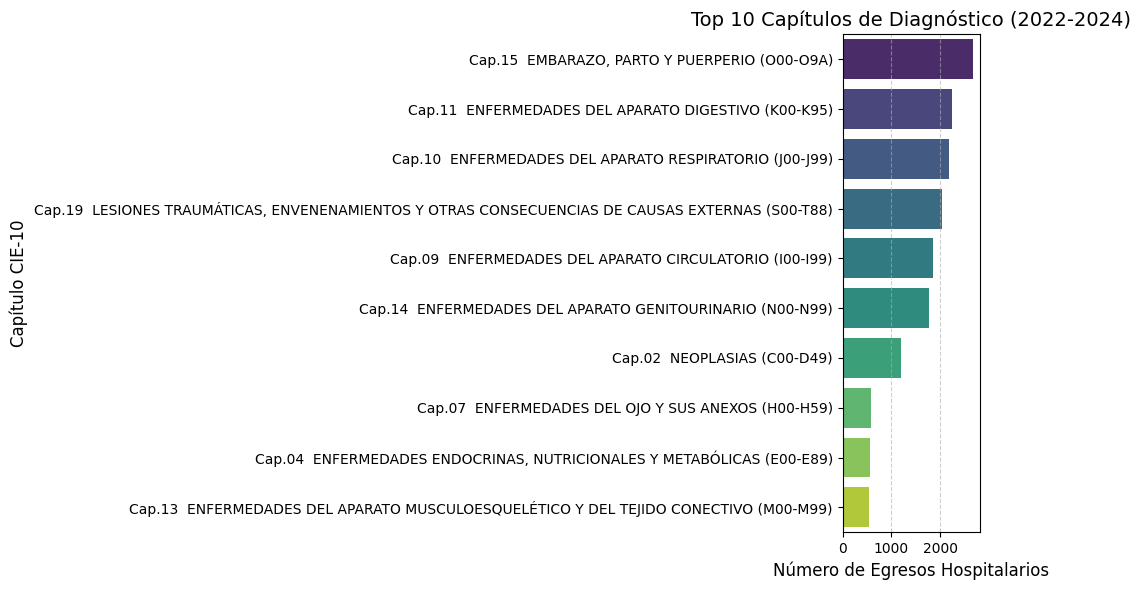

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Agrupar y contar por Capítulo
top_chapters = grd_com["Capítulo"].value_counts().head(10)

# 2. Crear el gráfico de barras horizontales
plt.figure(figsize=(10, 6))
sns.barplot(x=top_chapters.values, y=top_chapters.index, palette="viridis")

plt.title('Top 10 Capítulos de Diagnóstico (2022-2024)', fontsize=14)
plt.xlabel('Número de Egresos Hospitalarios', fontsize=12)
plt.ylabel('Capítulo CIE-10', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Las categorías que dominan las hospitalizaciones son: Cap.15  EMBARAZO, PARTO Y PUERPERIO (O00-O9A) y Cap.11  ENFERMEDADES DEL APARATO DIGESTIVO (K00-K95)

B.1.2 Top specific diagnoses


/tmp/ipykernel_27638/1828449038.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_diagnoses.values, y=top_diagnoses.index, palette="magma")


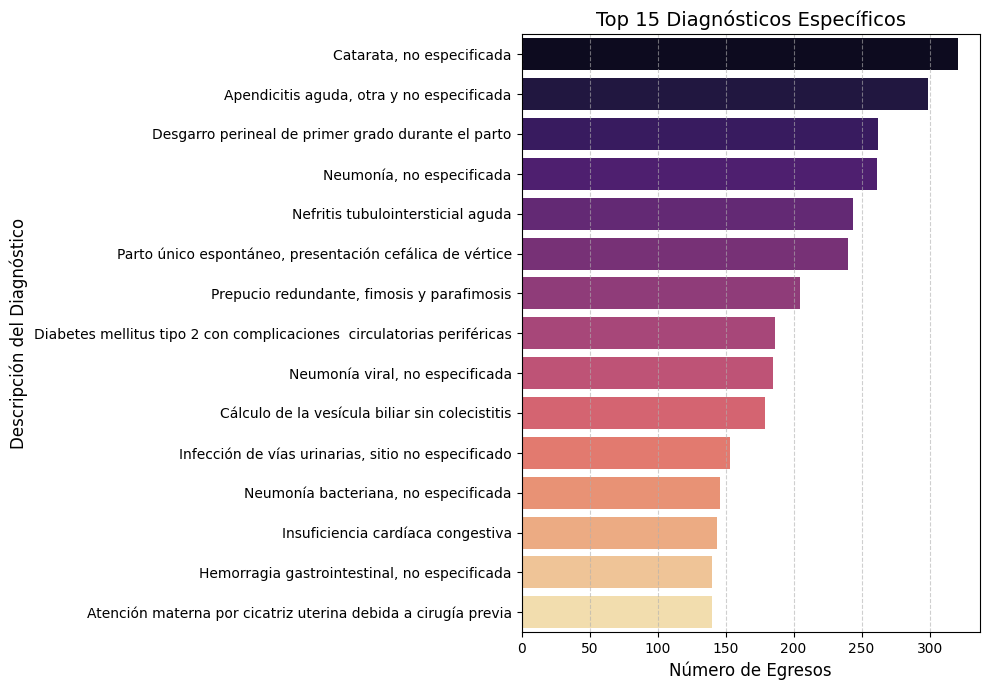

In [60]:
# 1. Agrupar y contar por Descripción (Top 15)
top_diagnoses = grd_com["Descripción"].value_counts().head(15)

# 2. Crear el gráfico
plt.figure(figsize=(10, 7))
sns.barplot(x=top_diagnoses.values, y=top_diagnoses.index, palette="magma")

plt.title('Top 15 Diagnósticos Específicos', fontsize=14)
plt.xlabel('Número de Egresos', fontsize=12)
plt.ylabel('Descripción del Diagnóstico', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

B.1.3 Diagnostic chapters by nationality

/tmp/ipykernel_27638/496096154.py:24: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


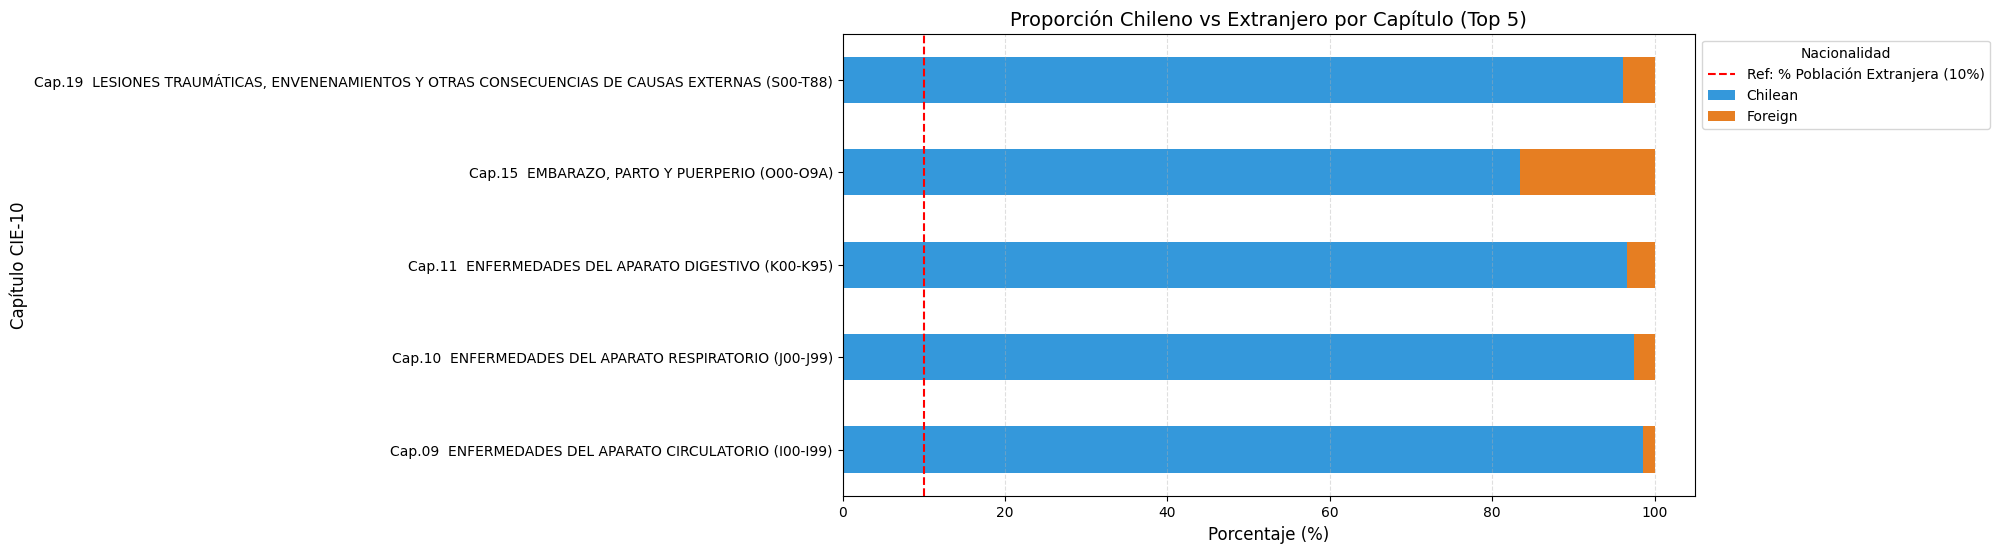

In [59]:
# 1. Obtener los top 5 capítulos
top_5_chapters = grd_com["Capítulo"].value_counts().head(5).index

# 2. Filtrar el dataframe para estos 5 capítulos
df_top5_cap = grd_com[grd_com["Capítulo"].isin(top_5_chapters)]

# 3. Calcular la proporción (share)
# Creamos tabla cruzada y normalizamos por filas para tener porcentajes
prop_chapters = pd.crosstab(df_top5_cap["Capítulo"], df_top5_cap["nat_group"], normalize='index') * 100

# 4. Graficar (Barras apiladas)
prop_chapters.plot(kind='barh', stacked=True, figsize=(11, 6), color=['#3498db', '#e67e22'])

# Línea de referencia del % de extranjeros en la población (ajusta según Tarea 1)
# Si en tu Tarea 1 los extranjeros son aprox 10%, dejamos 10.0
plt.axvline(x=10.0, color='red', linestyle='--', label='Ref: % Población Extranjera (10%)')

plt.title('Proporción Chileno vs Extranjero por Capítulo (Top 5)', fontsize=14)
plt.xlabel('Porcentaje (%)', fontsize=12)
plt.ylabel('Capítulo CIE-10', fontsize=12)
plt.legend(title='Nacionalidad', bbox_to_anchor=(1, 1))
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

Sobre-representación en Obstetricia: El hallazgo más relevante es en el Capítulo 15 (Embarazo, parto y puerperio). Aquí, la barra naranja supera significativamente la línea roja de referencia, alcanzando casi un 18-20% del total de egresos de ese capítulo. Esto indica que la población extranjera utiliza proporcionalmente más los servicios de maternidad, lo cual es consistente con perfiles migratorios de personas jóvenes en edad fértil.

Sub-representación en enfermedades crónicas y otros: En los capítulos de Enfermedades del Aparato Circulatorio (Cap. 09), Respiratorio (Cap. 10) y Digestivo (Cap. 11), la población extranjera está sub-representada (la barra naranja no alcanza la línea del 10%). Esto puede explicarse por el "efecto del migrante sano" (personas que migran suelen ser más jóvenes y sanas) o por posibles barreras de acceso a la salud para tratamientos de patologías crónicas.

Lesiones y causas externas: En el Capítulo 19, la proporción se acerca más al promedio poblacional, aunque sigue estando ligeramente por debajo del 10%.

B.2 Length of Stay & Severity

B.2.1 Length of stay by nationality


B.2.1 Estadísticas de días de estancia (los):


,nat_group,mean,median
0,Chilean,6.722379,3.0
1,Foreign,5.010112,3.0


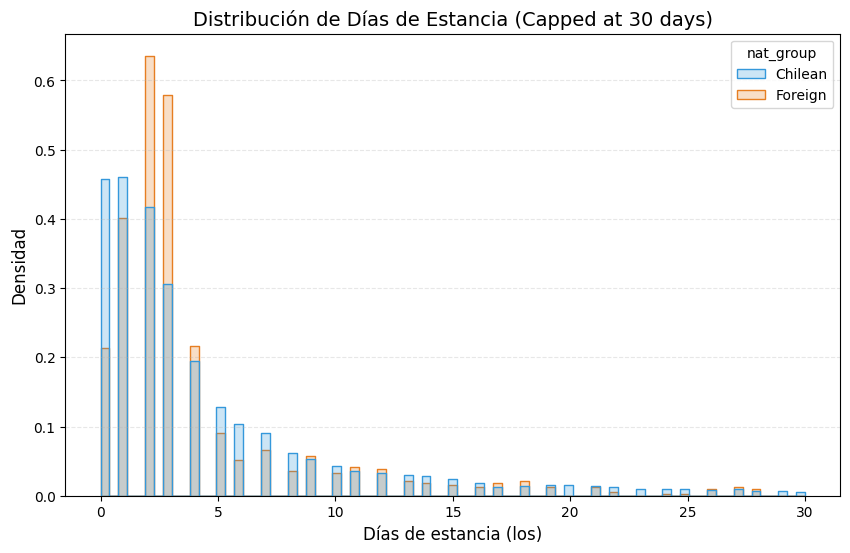

In [58]:
# 1. Calcular media y mediana de 'los' por grupo
los_stats = grd_com.groupby("nat_group")["los"].agg(['mean', 'median']).reset_index()

print("B.2.1 Estadísticas de días de estancia (los):")
display(los_stats)

# 2. Graficar distribución (Histrogramas solapados)
plt.figure(figsize=(10, 6))

# Filtramos hasta 30 días para mejor visibilidad según pide el PDF
sns.histplot(data=grd_com[grd_com["los"] <= 30],
             x="los",
             hue="nat_group",
             element="step",
             stat="density",
             common_norm=False,
             palette=['#3498db', '#e67e22'])

plt.title('Distribución de Días de Estancia (Capped at 30 days)', fontsize=14)
plt.xlabel('Días de estancia (los)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()


La población extranjera presenta un marcado pico de estadía en los días 2 y 3, asociado principalmente a partos y maternidad. Por el contrario, la población chilena muestra una mayor frecuencia de egresos rápidos (días 0-1), reflejando una carga de salud más diversa y distribuida que la población migrante.

B.2.2 Severity distribution

Conteos por categoría de severidad:
severidad_txt
1: Menor            6390
2: Moderado         5507
3: Mayor            4660
0: Sin Severidad    2019
Name: count, dtype: int64


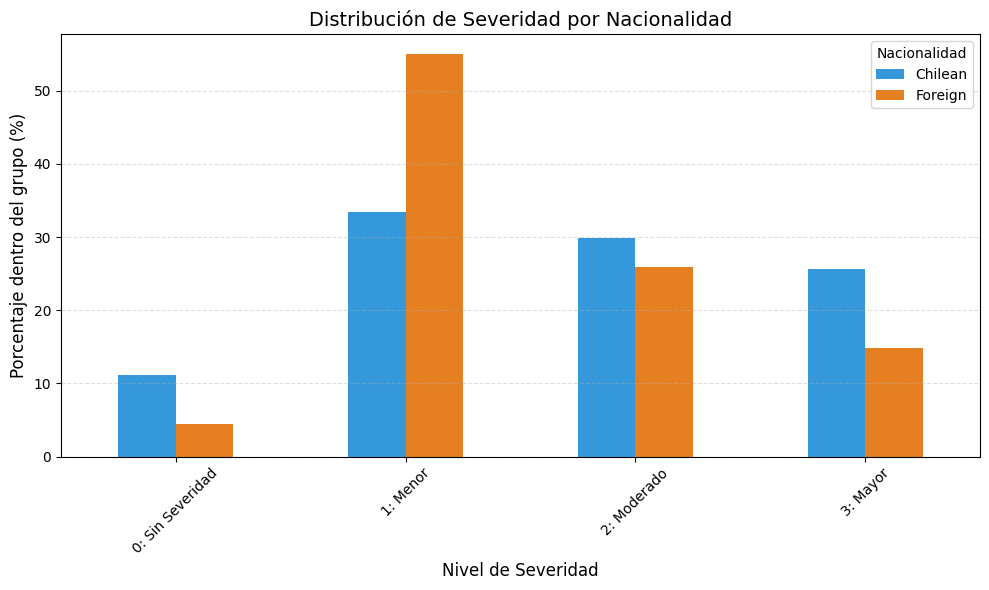

In [57]:
# Limpiar la columna de severidad (convertir a número, manejar errores)
# Usamos pd.to_numeric para convertir strings o floats a números reales
grd_com["IR_29301_SEVERIDAD_NUM"] = pd.to_numeric(grd_com["IR_29301_SEVERIDAD"], errors='coerce')

# Definir etiquetas (las claves ahora son números para que coincidan)
severidad_labels = {
    0.0: "0: Sin Severidad",
    1.0: "1: Menor",
    2.0: "2: Moderado",
    3.0: "3: Mayor"
}

# Aplicar el mapeo
grd_com["severidad_txt"] = grd_com["IR_29301_SEVERIDAD_NUM"].map(severidad_labels).fillna("Desconocido")

# --- DEBUG: Imprimir conteos para verificar antes de graficar ---
print("Conteos por categoría de severidad:")
print(grd_com["severidad_txt"].value_counts())

# Crear la tabla cruzada para el gráfico
sev_prop = pd.crosstab(grd_com["severidad_txt"], grd_com["nat_group"], normalize='columns') * 100
sev_prop = sev_prop.astype(float)

# Graficar (excluyendo 'Desconocido' si quieres un gráfico más limpio)
plt.figure(figsize=(10, 6))
# Si hay muchos 'Desconocido', puedes usar sev_prop.drop("Desconocido", errors='ignore')
sev_prop.plot(kind='bar', ax=plt.gca(), color=['#3498db', '#e67e22'])

plt.title('Distribución de Severidad por Nacionalidad', fontsize=14)
plt.xlabel('Nivel de Severidad', fontsize=12)
plt.ylabel('Porcentaje dentro del grupo (%)', fontsize=12)
plt.xticks(rotation=45) # Rotamos para que se lea mejor
plt.legend(title='Nacionalidad')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

B.2.3 Discharge type

In [31]:
# Ver distribución general de TIPOALTA
print("Distribución de tipos de alta:")
print(grd_com["TIPOALTA"].value_counts())

# Calcular tasa de mortalidad (% de FALLECIDO)
def calc_mortality(group):
    total = len(group)
    fallecidos = len(group[group["TIPOALTA"].str.contains("FALLECIDO", na=False, case=False)])
    return (fallecidos / total) * 100

mortality_rates = grd_com.groupby("nat_group").apply(calc_mortality)

print("\nB.2.3 Tasa de Mortalidad Hospitalaria (%):")
print(mortality_rates)

# Mostrar tabla pequeña comparativa
mort_table = mortality_rates.reset_index(name='Mortality Rate (%)')
display(mort_table)

Distribución de tipos de alta:
TIPOALTA
DOMICILIO                                        15230
HOSPITALIZACIÓN DOMICILIARIA                      1136
DERIVACIÓN OTRO HOSPITAL DEL SERVICIO              565
FALLECIDO                                          549
DERIVACIÓN INST. PRIVADA (COMPRA DE SERVICIOS      370
ALTA VOLUNTARIA                                    328
DERIVACIÓN OTRO HOSPITAL DE LA RED NACIONAL        204
FUGA DEL PACIENTE                                  136
DERIVACIÓN A OTROS CENTROS (CÁRCEL, HOGAR DE        53
DERIVACIÓN INST. PRIVADA (VOLUNTARIO)                5
Name: count, dtype: int64

B.2.3 Tasa de Mortalidad Hospitalaria (%):
nat_group
Chilean    3.053262
Foreign    1.011236
dtype: float64


/tmp/ipykernel_27638/1073727649.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mortality_rates = grd_com.groupby("nat_group").apply(calc_mortality)


,nat_group,Mortality Rate (%)
0,Chilean,3.053262
1,Foreign,1.011236


B.3 Spatial View

B.3.1 Choropleth: hospitalization rate by comuna

Comunas listas en el mapa final: ['El Bosque', 'Lo Espejo', 'Pirque', 'Isla de Maipo']


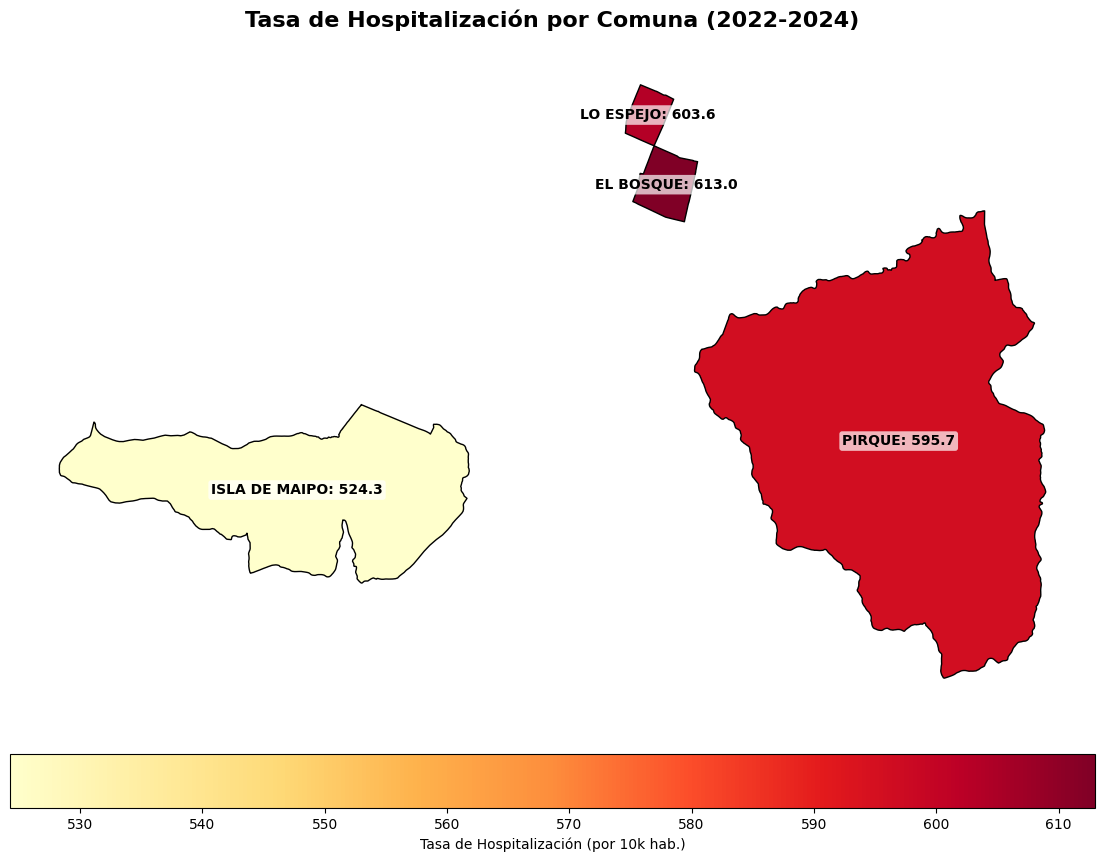

In [56]:
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd

# Preparar datos de hospitalización
# Usamos grd_summary que ya tiene las 4 comunas calculadas
grd_map_data = grd_summary.copy()
grd_map_data['codigo_comuna'] = grd_map_data['codigo_comuna'].astype(int)

# Cargar la capa de comunas especificando 'Comunal_CPV24'
path_carto = "/content/drive/MyDrive/Colab Notebooks/Tarea 1/Cartografia_censo2024_Pais.gpkg"
# Cargamos la capa comunal
comunas_gdf = gpd.read_file(path_carto, layer='Comunal_CPV24')

# Filtrar por tus 4 comunas usando 'CUT'
mis_4_codigos = [13105, 13116, 13202, 13603]
mapa_4_comunas = comunas_gdf[comunas_gdf['CUT'].astype(int).isin(mis_4_codigos)].copy()
mapa_4_comunas['CUT_int'] = mapa_4_comunas['CUT'].astype(int)

# Unir el mapa con tus datos de GRD
mapa_final = mapa_4_comunas.merge(grd_map_data, left_on='CUT_int', right_on='codigo_comuna')

# Verificación en consola para estar seguros
print(f"Comunas listas en el mapa final: {mapa_final['nombre_comuna'].tolist()}")

# Graficar mapa de población
fig, ax = plt.subplots(figsize=(14, 12))

mapa_final.plot(column='grd_rate_per_10k',
                cmap='YlOrRd',
                legend=True,
                edgecolor='black',
                linewidth=1,
                ax=ax,
                legend_kwds={'label': "Tasa de Hospitalización (por 10k hab.)",
                             'orientation': "horizontal", 'pad': 0.05})

# Etiquetas centradas
for idx, row in mapa_final.iterrows():
    centro = row.geometry.centroid
    # Formato: "COMUNA: TASA"
    texto = f"{row['nombre_comuna'].upper()}: {row['grd_rate_per_10k']:.1f}"

    ax.annotate(text=texto,
                xy=(centro.x, centro.y),
                ha='center', va='center',
                fontsize=10, fontweight='bold', color='black',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))

plt.title('Tasa de Hospitalización por Comuna (2022-2024)', fontsize=16, fontweight='bold', pad=20)
ax.axis('off')
plt.show()

B.4 Comuna-Level GRD Summary Table

In [55]:
import os

# Definir la función que calcula las métricas por cada comuna (grupo)
def build_grd_summary_logic(group):
    # Calcular promedios de estancia (Length of Stay)
    mean_los = group["los"].mean()
    mean_los_chilean = group[group["nat_group"] == "Chilean"]["los"].mean()
    mean_los_foreign = group[group["nat_group"] == "Foreign"]["los"].mean()

    # Calcular promedio de severidad (convertir a numérico por seguridad)
    mean_sev = pd.to_numeric(group["IR_29301_SEVERIDAD"], errors='coerce').mean()

    # Calcular tasa de mortalidad (% de altas que son fallecimientos)
    total_egresos = len(group)
    fallecidos = len(group[group["TIPOALTA"].str.contains("FALLECIDO", na=False, case=False)])
    mortality_rate = (fallecidos / total_egresos) * 100

    # Obtener los nombres de los Top 3 capítulos diagnósticos
    top_3_chapters = group["Capítulo"].value_counts().head(3).index.tolist()
    top_3_str = ", ".join(top_3_chapters)

    return pd.Series({
        "grd_total": total_egresos,
        "grd_chilean": len(group[group["nat_group"] == "Chilean"]),
        "grd_foreign": len(group[group["nat_group"] == "Foreign"]),
        "grd_mean_los": mean_los,
        "grd_mean_los_chilean": mean_los_chilean,
        "grd_mean_los_foreign": mean_los_foreign,
        "grd_mean_severity": mean_sev,
        "grd_mortality_rate": mortality_rate,
        "grd_top3_chapters": top_3_str
    })

# Agrupar el dataset GRD filtrado y aplicar la lógica
grd_summary_raw = grd_com.groupby("COMUNA").apply(build_grd_summary_logic).reset_index()

# Unir con t1_summary para obtener códigos, nombres reales y población
# Preparamos el nombre en mayúsculas en t1_summary para que el cruce sea exacto
t1_summary['nombre_comuna_upper'] = t1_summary['nombre_comuna'].str.upper()

grd_summary = pd.merge(grd_summary_raw,
                       t1_summary[['codigo_comuna', 'nombre_comuna', 'pop_total', 'nombre_comuna_upper']],
                       left_on="COMUNA",
                       right_on="nombre_comuna_upper")

# Cálculos finales de porcentajes y tasas
grd_summary["grd_pct_foreign"] = (grd_summary["grd_foreign"] / grd_summary["grd_total"]) * 100
grd_summary["grd_rate_per_10k"] = (grd_summary["grd_total"] / grd_summary["pop_total"]) * 10000

# Seleccionar y ordenar las columnas exactamente como pide el PDF
cols_finales_grd = [
    "codigo_comuna",
    "nombre_comuna",
    "grd_total",
    "grd_chilean",
    "grd_foreign",
    "grd_pct_foreign",
    "grd_mean_los",
    "grd_mean_los_chilean",
    "grd_mean_los_foreign",
    "grd_mean_severity",
    "grd_mortality_rate",
    "grd_top3_chapters",
    "grd_rate_per_10k"
]
grd_summary = grd_summary[cols_finales_grd]

# Guardar la tabla en Drive
output_dir = "/content/drive/MyDrive/Colab Notebooks/Tarea 2/output/"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

output_file_grd = os.path.join(output_dir, "tarea2_grd_summary.csv")
grd_summary.to_csv(output_file_grd, index=False)

print(f"Punto B.4 finalizado. Tabla guardada en: {output_file_grd}")

# Mostrar resultado final
display(grd_summary)

Punto B.4 finalizado. Tabla guardada en: /content/drive/MyDrive/Colab Notebooks/Tarea 2/output/tarea2_grd_summary.csv


/tmp/ipykernel_27638/3756226359.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grd_summary_raw = grd_com.groupby("COMUNA").apply(build_grd_summary_logic).reset_index()


,codigo_comuna,nombre_comuna,grd_total,grd_chilean,grd_foreign,grd_pct_foreign,grd_mean_los,grd_mean_los_chilean,grd_mean_los_foreign,grd_mean_severity,grd_mortality_rate,grd_top3_chapters,grd_rate_per_10k
0,13105,El Bosque,9517,9046,471,4.949039,7.223915,7.369335,4.430998,1.774614,3.425449,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A),...",612.983634
1,13603,Isla de Maipo,2059,1989,70,3.399709,5.699854,5.733534,4.742857,1.619233,1.602720,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,524.265417
2,13116,Lo Espejo,5269,4949,320,6.073259,6.763143,6.819357,5.893750,1.626684,2.770924,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A),...",603.585543
3,13202,Pirque,1731,1702,29,1.675332,4.176776,4.157462,5.310345,1.496245,2.541883,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A),...",595.664143
